## 1. Project Information

# FinSight AI

## Notebook 04 - Exploratory Data Analysis

### Objective

Explore the Financial News Dataset and understand

- News distribution
- Companies
- Publishers
- Dates
- Headlines

No preprocessing is performed in this notebook.

## 2. Install Libraries

In [1]:
!pip install -q plotly

## 3. Imports

In [2]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## 4. Project Paths

In [3]:
PROJECT_ROOT = "/content/drive/MyDrive/FinSight_AI"

INTERIM_DATA = os.path.join(PROJECT_ROOT, "data/interim")

REPORT_PATH = os.path.join(PROJECT_ROOT, "reports")

FIGURE_PATH = os.path.join(REPORT_PATH, "figures")

os.makedirs(FIGURE_PATH, exist_ok=True)

## 5. Load Dataset

In [4]:
master_df = pd.read_parquet(
    os.path.join(
        INTERIM_DATA,
        "master_news_dataset.parquet"
    )
)

master_df.head()

,news_id,headline,url,publisher,published_date,ticker,source,year,month,day,weekday,hour,headline_length,word_count,has_time
0,1,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A,analyst,2020,6,5,Friday,14,39,7,True
1,2,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A,analyst,2020,6,3,Wednesday,14,42,7,True
2,3,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A,analyst,2020,5,26,Tuesday,8,29,5,True
3,4,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A,analyst,2020,5,22,Friday,16,44,7,True
4,5,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A,analyst,2020,5,22,Friday,15,87,14,True


## 6. Dataset Overview

In [5]:
overview = pd.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Unique Companies",

        "Unique Publishers",

        "Date Range"

    ],

    "Value":[

        len(master_df),

        len(master_df.columns),

        master_df["ticker"].nunique(),

        master_df["publisher"].nunique(),

        f"{master_df['published_date'].min().date()}  →  {master_df['published_date'].max().date()}"

    ]

})

overview

,Metric,Value
0,Rows,3215315
1,Columns,15
2,Unique Companies,6619
3,Unique Publishers,1047
4,Date Range,2009-02-14 → 2020-06-11


## 7. Dataset Info

In [6]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3215315 entries, 0 to 3215314
Data columns (total 15 columns):
 #   Column           Dtype              
---  ------           -----              
 0   news_id          int64              
 1   headline         object             
 2   url              object             
 3   publisher        category           
 4   published_date   datetime64[ns, UTC]
 5   ticker           category           
 6   source           category           
 7   year             int32              
 8   month            int32              
 9   day              int32              
 10  weekday          category           
 11  hour             int32              
 12  headline_length  int64              
 13  word_count       int64              
 14  has_time         bool               
dtypes: bool(1), category(4), datetime64[ns, UTC](1), int32(4), int64(3), object(2)
memory usage: 218.1+ MB


## 8. Missing Values

In [7]:
missing = pd.DataFrame({

    "Missing Values": master_df.isnull().sum(),

    "Percentage": (
        master_df.isnull().mean()*100
    ).round(2)

})

missing

,Missing Values,Percentage
news_id,0,0.0
headline,0,0.0
url,0,0.0
publisher,0,0.0
published_date,0,0.0
ticker,0,0.0
source,0,0.0
year,0,0.0
month,0,0.0
day,0,0.0


## 9. Duplicate Check

In [8]:
duplicates = master_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## 10. Numeric Summary

In [9]:
master_df.describe().T

,count,mean,std,min,25%,50%,75%,max
news_id,3215315.0,1.607658e+06,928181.634730,1.0,803829.5,1607658.0,2411486.5,3215315.0
year,3215315.0,2.015905e+03,2.784020,2009.0,2014.0,2016.0,2018.0,2020.0
month,3215315.0,6.306400e+00,3.465721,1.0,3.0,6.0,9.0,12.0
day,3215315.0,1.553594e+01,8.821573,1.0,8.0,15.0,23.0,31.0
hour,3215315.0,2.521237e-01,1.953310,0.0,0.0,0.0,0.0,23.0
headline_length,3215315.0,6.429519e+01,31.808329,2.0,45.0,58.0,76.0,512.0
word_count,3215315.0,1.016966e+01,4.949958,1.0,7.0,9.0,12.0,77.0


## 11. Categorical Summary

In [10]:
master_df.describe(include="object").T

,count,unique,top,freq
headline,3215315,1649971,Benzinga's Top Upgrades,5435
url,3215315,1758505,https://www.benzinga.com/news/20/03/15538835/s...,1704


## 12. Dataset Memory Usage

In [11]:
memory = master_df.memory_usage(
    deep=True
).sum() / 1024**2

print(f"Dataset Size : {memory:.2f} MB")

Dataset Size : 1018.80 MB


## 13. News Distribution by Year

In [12]:
yearly_news = (
    master_df
    .groupby("year")
    .size()
    .reset_index(name="news_count")
)

yearly_news

,year,news_count
0,2009,11354
1,2010,88536
2,2011,171757
3,2012,224064
4,2013,210212
5,2014,244348
6,2015,411674
7,2016,373746
8,2017,285294
9,2018,478581


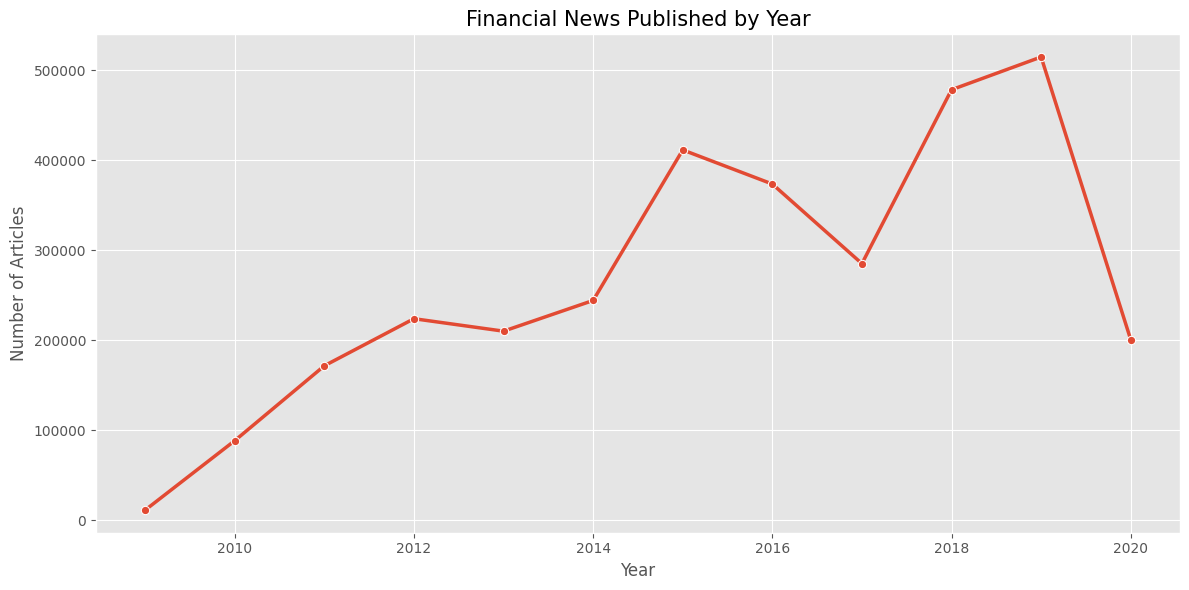

In [13]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_news,
    x="year",
    y="news_count",
    marker="o",
    linewidth=2.5
)

plt.title("Financial News Published by Year", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "news_by_year.png"
    ),
    dpi=300
)

plt.show()

## 14. News Distribution by Month

In [14]:
month_names = {
    1:"Jan",
    2:"Feb",
    3:"Mar",
    4:"Apr",
    5:"May",
    6:"Jun",
    7:"Jul",
    8:"Aug",
    9:"Sep",
    10:"Oct",
    11:"Nov",
    12:"Dec"
}

monthly_news = (
    master_df
    .groupby("month")
    .size()
    .reset_index(name="news_count")
)

monthly_news["month_name"] = (
    monthly_news["month"]
    .map(month_names)
)

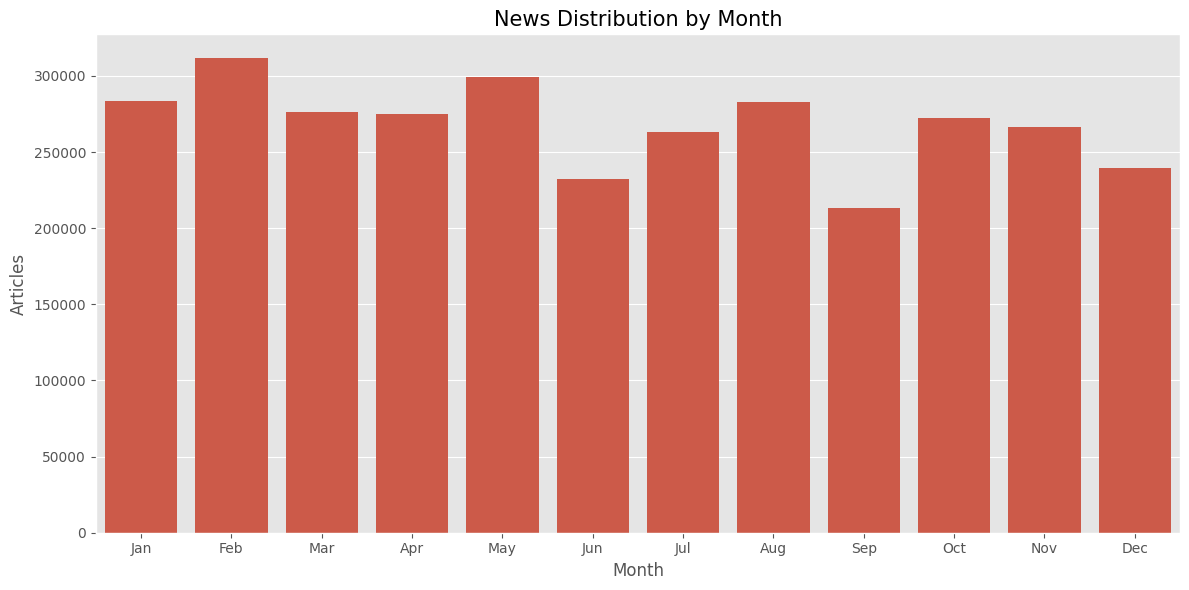

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=monthly_news,
    x="month_name",
    y="news_count"
)

plt.title("News Distribution by Month", fontsize=15)

plt.xlabel("Month")

plt.ylabel("Articles")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "news_by_month.png"
    ),
    dpi=300
)

plt.show()

## 15. News Distribution by Weekday

In [16]:
weekday_order = [

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday",

    "Sunday"

]

weekday_news = (

    master_df

    .groupby("weekday")

    .size()

    .reindex(weekday_order)

    .reset_index(name="news_count")

)

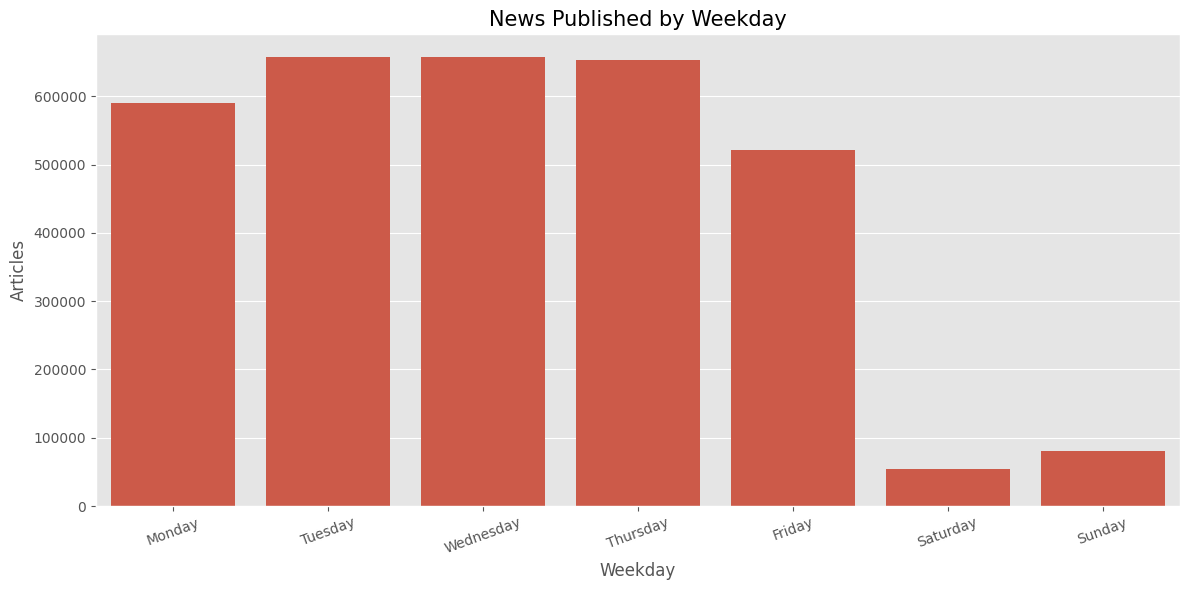

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=weekday_news,

    x="weekday",

    y="news_count"

)

plt.xticks(rotation=20)

plt.title("News Published by Weekday", fontsize=15)

plt.xlabel("Weekday")

plt.ylabel("Articles")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "news_by_weekday.png"

    ),

    dpi=300

)

plt.show()

## 16. News Distribution by Hour

In [43]:
hourly_news = (
    master_df[
        (master_df["has_time"]) &
        (master_df["hour"] != 0)
    ]
    .groupby("hour")
    .size()
    .reset_index(name="news_count")
)

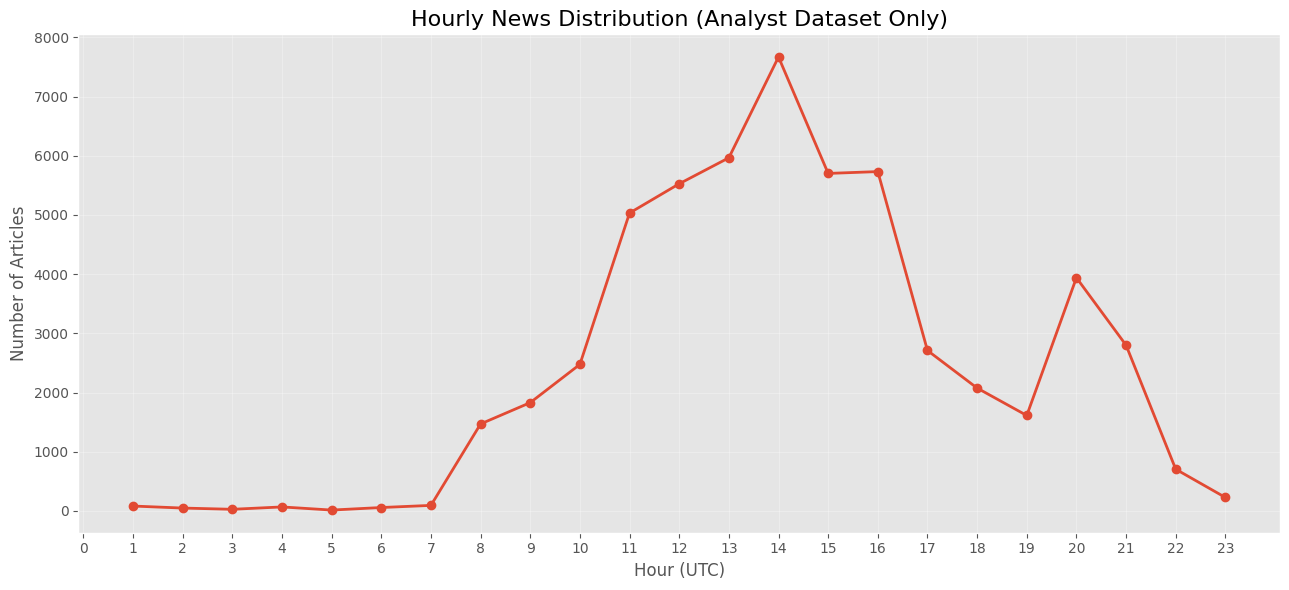

In [44]:
plt.figure(figsize=(13,6))

plt.plot(
    hourly_news["hour"],
    hourly_news["news_count"],
    marker="o",
    linewidth=2
)

plt.xticks(range(24))

plt.title("Hourly News Distribution (Analyst Dataset Only)", fontsize=16)

plt.xlabel("Hour (UTC)")

plt.ylabel("Number of Articles")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "news_by_hour.png"
    ),
    dpi=300
)

plt.show()

### Note

The analyst dataset contains full publication timestamps.

The partner dataset stores only publication dates, so hour-level analysis is performed using only analyst articles.

Daily, monthly, and yearly analyses use the complete merged dataset.

In [20]:
coverage = pd.DataFrame({

    "Source": [
        "Analyst",
        "Partner"
    ],

    "Original Time Available": [
        "Yes",
        "No"
    ],

    "Articles": [

        (master_df["source"]=="analyst").sum(),

        (master_df["source"]=="partner").sum()

    ]

})

coverage

,Source,Original Time Available,Articles
0,Analyst,Yes,1395973
1,Partner,No,1819342


## 17. Top 20 Companies

In [21]:
top_companies = (
    master_df.groupby("ticker")
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="news_count")
)

top_companies.columns = [

    "ticker",

    "news_count"

]

top_companies

,ticker,news_count
0,KR,5061
1,GILD,4938
2,DISH,4544
3,EWJ,4483
4,MDT,4421
5,MYL,4416
6,HD,4415
7,JWN,4361
8,FDX,4358
9,FCAU,4318


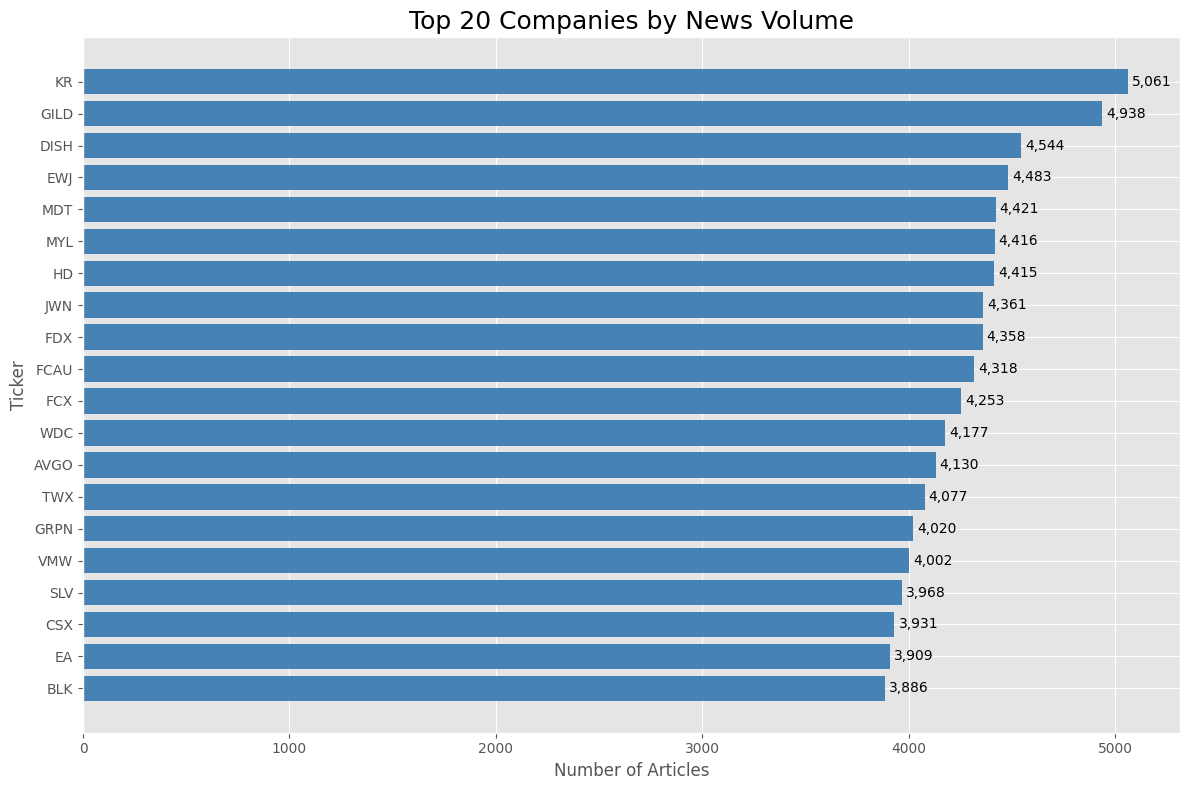

In [22]:
plt.figure(figsize=(12,8))

bars = plt.barh(
    top_companies["ticker"],
    top_companies["news_count"],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title("Top 20 Companies by News Volume", fontsize=18)

plt.xlabel("Number of Articles")

plt.ylabel("Ticker")

for bar in bars:
    plt.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

## 18. Top Publishers

In [23]:
top_publishers = (
    master_df.groupby("publisher")
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="news_count")
)


top_publishers.columns = [

    "publisher",

    "news_count"

]

top_publishers

,publisher,news_count
0,Seeking Alpha,891476
1,Zacks,453995
2,Paul Quintaro,227495
3,GuruFocus,210543
4,Lisa Levin,186716
5,Benzinga Newsdesk,150392
6,Investor's Business Daily,133448
7,Charles Gross,96558
8,Monica Gerson,82056
9,webmaster,63680


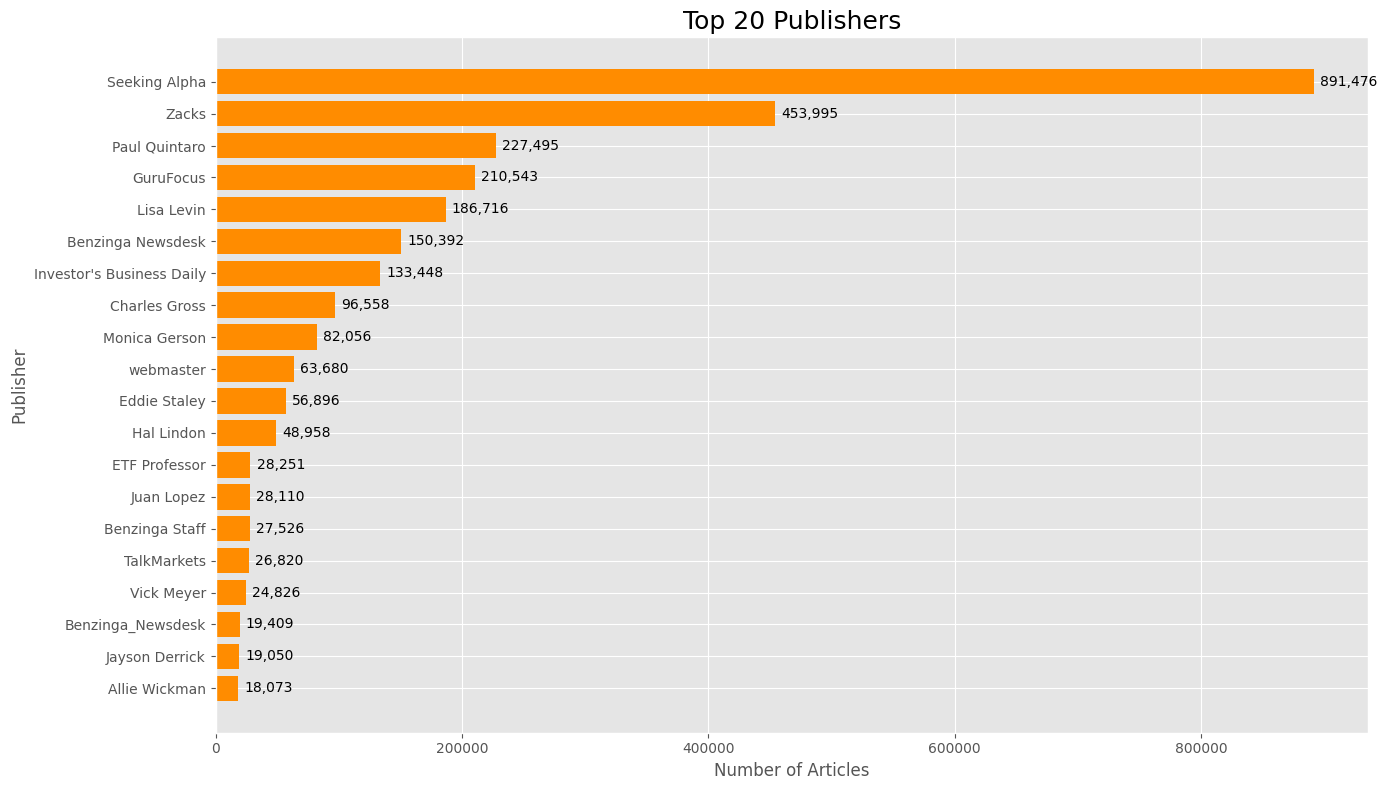

In [24]:
plt.figure(figsize=(14,8))

bars = plt.barh(
    top_publishers["publisher"],
    top_publishers["news_count"],
    color="darkorange"
)

plt.gca().invert_yaxis()

plt.title("Top 20 Publishers", fontsize=18)

plt.xlabel("Number of Articles")

plt.ylabel("Publisher")

for bar in bars:
    plt.text(
        bar.get_width()+5000,
        bar.get_y()+bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

## 19.Headline Length Distribution

In [25]:
headline_stats = master_df["headline_length"].describe()

headline_stats

,headline_length
count,3.215315e+06
mean,6.429519e+01
std,3.180833e+01
min,2.000000e+00
25%,4.500000e+01
50%,5.800000e+01
75%,7.600000e+01
max,5.120000e+02


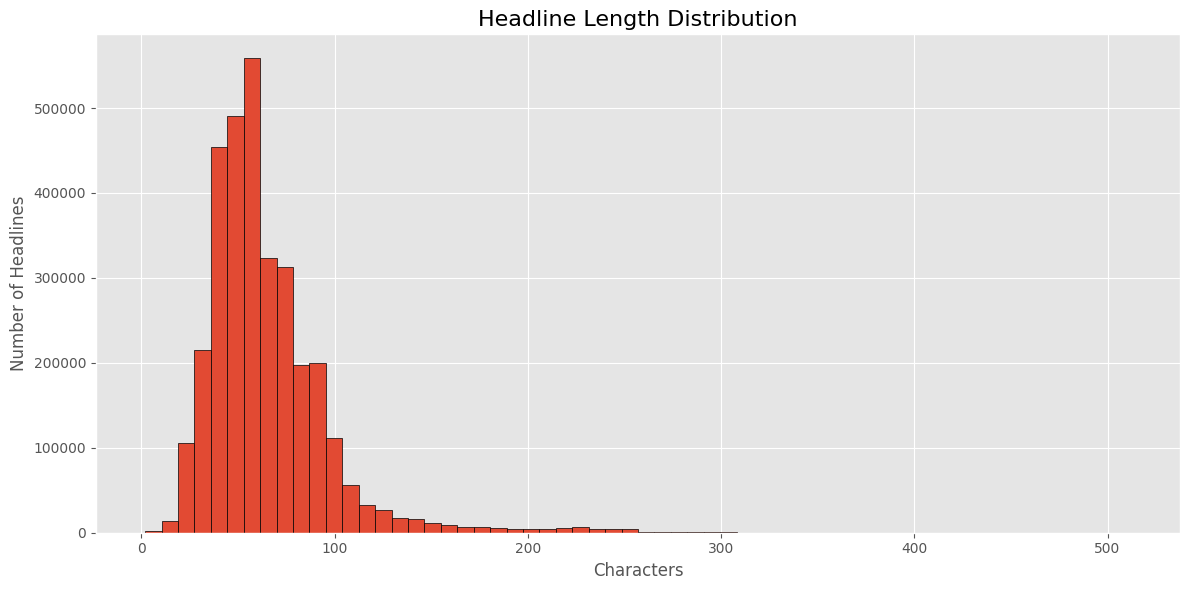

In [26]:
plt.figure(figsize=(12,6))

plt.hist(
    master_df["headline_length"],
    bins=60,
    edgecolor="black"
)

plt.title("Headline Length Distribution", fontsize=16)

plt.xlabel("Characters")

plt.ylabel("Number of Headlines")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "headline_length_distribution.png"
    ),
    dpi=300
)

plt.show()

## 20. Word Count Distribution

In [27]:
word_stats = master_df["word_count"].describe()

word_stats

,word_count
count,3.215315e+06
mean,1.016966e+01
std,4.949958e+00
min,1.000000e+00
25%,7.000000e+00
50%,9.000000e+00
75%,1.200000e+01
max,7.700000e+01


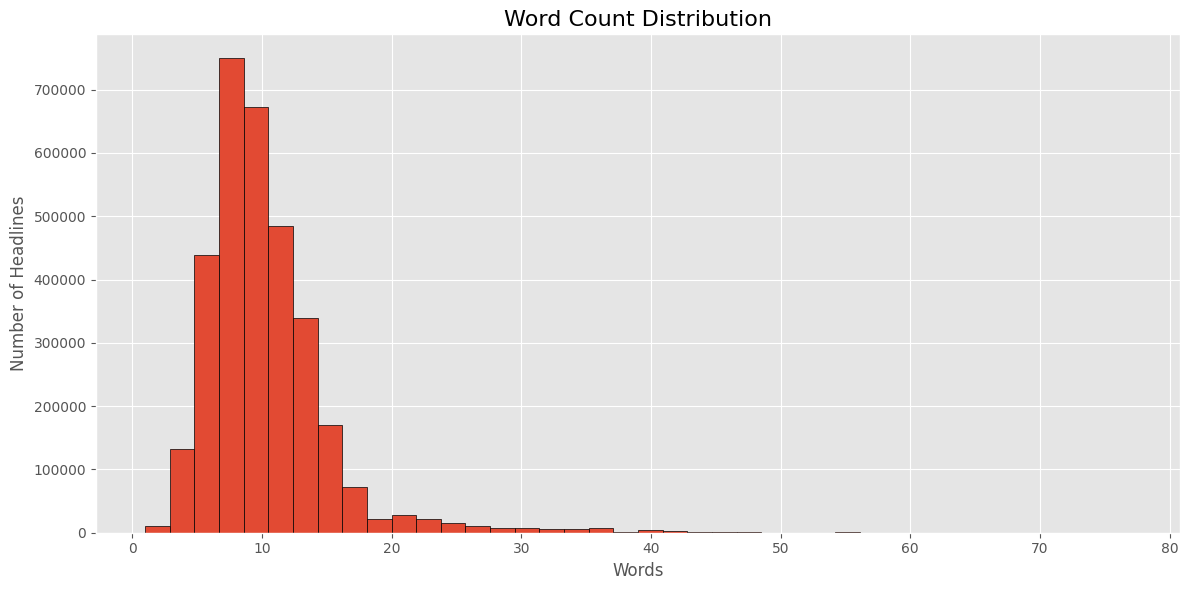

In [28]:
plt.figure(figsize=(12,6))

plt.hist(
    master_df["word_count"],
    bins=40,
    edgecolor="black"
)

plt.title("Word Count Distribution", fontsize=16)

plt.xlabel("Words")

plt.ylabel("Number of Headlines")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_PATH,
        "word_count_distribution.png"
    ),
    dpi=300
)

plt.show()

## 21. Top 30 Most Frequent Words

In [29]:
import re
from collections import Counter

In [30]:
text = " ".join(master_df["headline"].astype(str))

text = text.lower()

text = re.sub(r"[^a-z\s]", " ", text)

words = text.split()

len(words)

31415640

In [31]:
stopwords = {

"a","an","the","is","are","was","were","to","of","for","on",

"in","with","by","at","from","that","this","and","or","be",

"as","it","its","will","has","have","had","after","before",

"about","into","over","under","their","his","her","our"

}

filtered_words = [

word

for word in words

if word not in stopwords

and len(word) > 2

]

In [32]:
top_words = Counter(filtered_words).most_common(30)

top_words_df = pd.DataFrame(

    top_words,

    columns=[

        "Word",

        "Frequency"

    ]

)

top_words_df

,Word,Frequency
0,earnings,315760
1,stocks,313201
2,market,192246
3,analyst,190811
4,blog,177094
5,inc,152118
6,shares,142745
7,eps,141016
8,est,140828
9,stock,137974


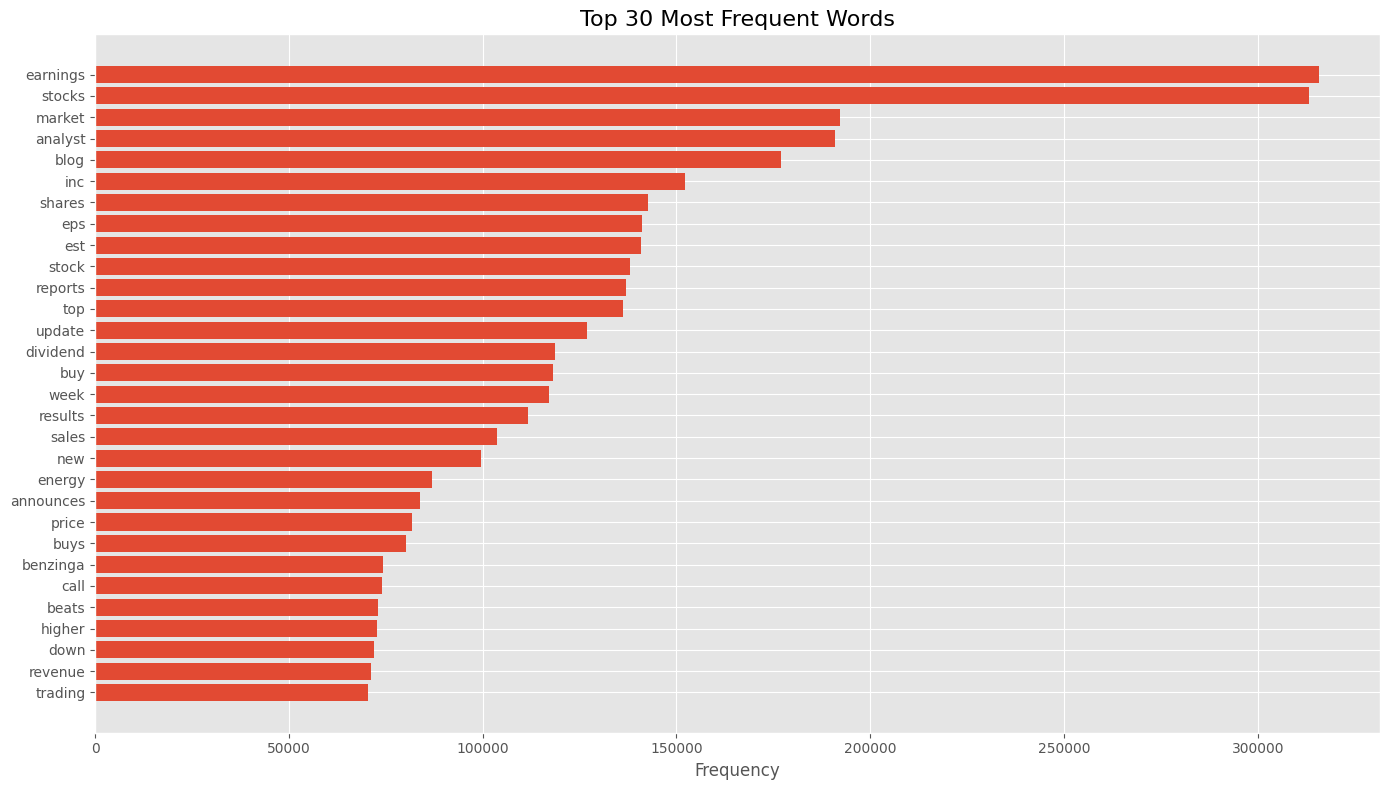

In [33]:
plt.figure(figsize=(14,8))

plt.barh(

    top_words_df["Word"],

    top_words_df["Frequency"]

)

plt.gca().invert_yaxis()

plt.title(

    "Top 30 Most Frequent Words",

    fontsize=16

)

plt.xlabel("Frequency")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "top_words.png"

    ),

    dpi=300

)

plt.show()

## 22. Company News Distribution

In [34]:
company_news = (

    master_df["ticker"]

    .value_counts()

)

In [35]:
company_news.describe()

,count
count,6619.000000
mean,485.770509
std,641.475068
min,1.000000
25%,58.000000
50%,251.000000
75%,622.000000
max,5061.000000


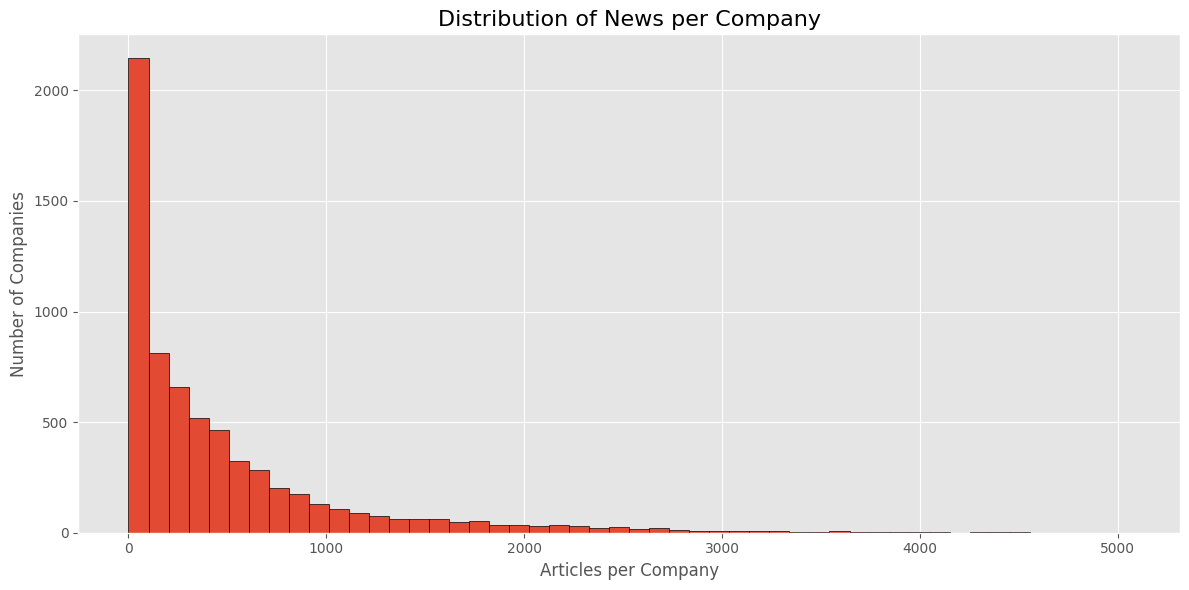

In [36]:
plt.figure(figsize=(12,6))

plt.hist(

    company_news,

    bins=50,

    edgecolor="black"

)

plt.title(

    "Distribution of News per Company",

    fontsize=16

)

plt.xlabel("Articles per Company")

plt.ylabel("Number of Companies")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "company_distribution.png"

    ),

    dpi=300

)

plt.show()

## 23. Publisher Distribution

In [37]:
publisher_news = (

    master_df["publisher"]

    .value_counts()

)

In [38]:
publisher_news.describe()

,count
count,1047.000000
mean,3070.978988
std,33809.748130
min,1.000000
25%,3.000000
50%,11.000000
75%,117.500000
max,891476.000000


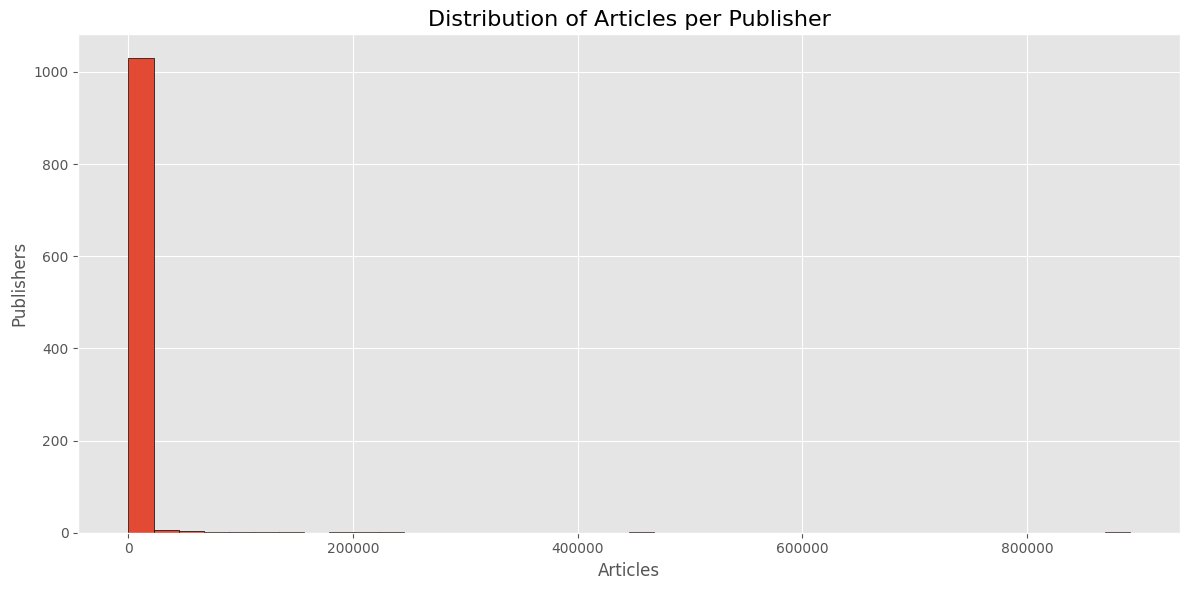

In [39]:
plt.figure(figsize=(12,6))

plt.hist(

    publisher_news,

    bins=40,

    edgecolor="black"

)

plt.title(

    "Distribution of Articles per Publisher",

    fontsize=16

)

plt.xlabel("Articles")

plt.ylabel("Publishers")

plt.tight_layout()

plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "publisher_distribution.png"

    ),

    dpi=300

)

plt.show()

## 24. EDA Summary

In [40]:
eda_summary = pd.DataFrame({

    "Metric":[

        "Total Articles",

        "Unique Companies",

        "Unique Publishers",

        "Average Headline Length",

        "Average Word Count"

    ],

    "Value":[

        len(master_df),

        master_df["ticker"].nunique(),

        master_df["publisher"].nunique(),

        round(master_df["headline_length"].mean(),2),

        round(master_df["word_count"].mean(),2)

    ]

})

eda_summary

,Metric,Value
0,Total Articles,3215315.00
1,Unique Companies,6619.00
2,Unique Publishers,1047.00
3,Average Headline Length,64.30
4,Average Word Count,10.17


## 25. Save Summary

In [41]:
eda_summary.to_csv(

    os.path.join(

        REPORT_PATH,

        "eda_summary.csv"

    ),

    index=False

)